In [56]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

root = Path.cwd()
root = root.parent.parent
sns.set_theme(style='whitegrid')
csv_path = root / "eval_results" / "model_comparison.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f'Successfully loaded {len(df)} records')
else:
    raise ValueError(f"The {csv_path} cannot be opened or doesn't exist")
df.head() 

Successfully loaded 42 records


,model_name,provider,model_id,scenario_id,scenario_category,task_type,valid_json,schema_pass,required_fields_present,must_include_pass,...,input_tokens,output_tokens,estimated_cost,specificity_score,tone_score,faithfullness_score,linkedin_readiness_score,refinement_quality_score,overall_quality_score,notes
0,openrouter_gpt_4o_mini,openrouter,openai/gpt-4o-mini,scenario_only_required_fields,required_only,generate,True,True,False,True,...,679.0,297.0,0.600399,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,openrouter_gpt_4o_mini,openrouter,openai/gpt-4o-mini,scenario_only_required_fields,required_only,refine,True,True,True,True,...,720.0,373.0,0.600481,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,openrouter_gpt_4o_mini,openrouter,openai/gpt-4o-mini,scenario_all_fields,all_fields,generate,True,True,True,True,...,789.0,457.0,0.600575,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,openrouter_gpt_4o_mini,openrouter,openai/gpt-4o-mini,scenario_all_fields,all_fields,refine,True,True,True,True,...,877.0,453.0,0.600585,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,openrouter_gpt_4o_mini,openrouter,openai/gpt-4o-mini,scenario_various_fields_sparse,various_fields,generate,True,True,False,True,...,669.0,175.0,0.600275,0.0,0.0,0.0,0.0,0.0,0.0,NaN


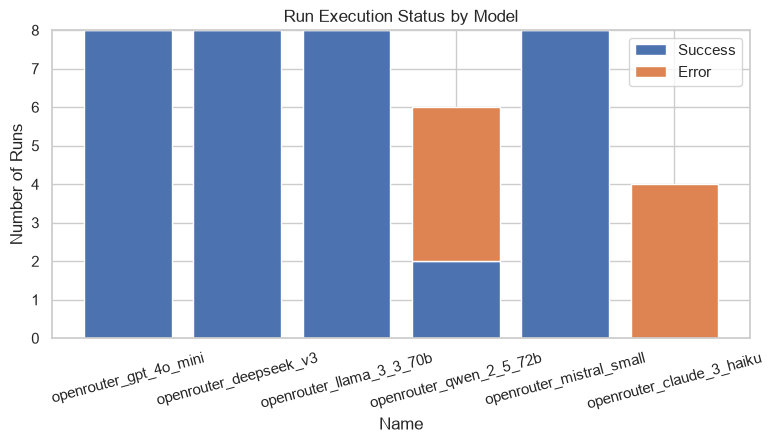

In [57]:
df['has_error'] = df['notes'].notna() | df['output_tokens'].isna()
errors_df = df[df['has_error']] 
valid_df = df[~df['has_error']].copy()

models = df['model_name'].unique()
success_counts = []
error_counts = []

for m in models:
    sub = df[df['model_name'] == m] 
    n_success = (sub['has_error'] == False).sum()
    n_error = (sub['has_error'] == True).sum()
    success_counts.append(n_success)
    error_counts.append(n_error)

plt.figure(figsize = (9, 4))
plt.bar(
    models, 
    success_counts, 
    label = 'Success',
)
plt.bar (
    models,
    error_counts,
    bottom=success_counts,
    label='Error',
)
plt.title ('Run Execution Status by Model')
plt.xlabel ('Name')
plt.ylabel ('Number of Runs')
plt.legend()
plt.xticks(rotation = 15)
plt.show()

In [58]:
pass_cols = [
    'valid_json',
    'schema_pass',
    'required_fields_present',
    'must_include_pass',
    'must_not_include_pass'
]

pass_cols = [
    'valid_json',
    'schema_pass',
    'required_fields_present',
    'must_include_pass',
    'must_not_include_pass',
]

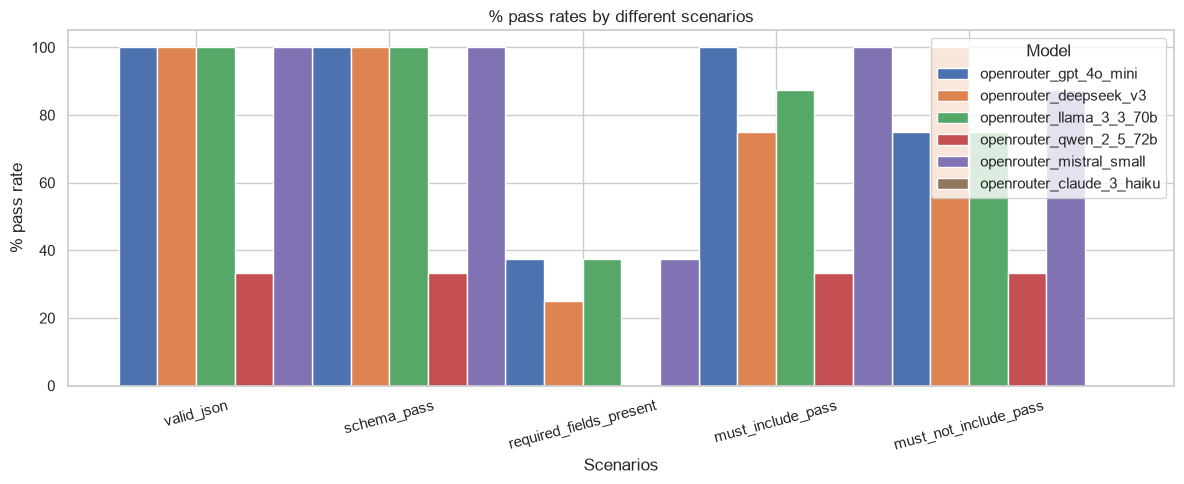

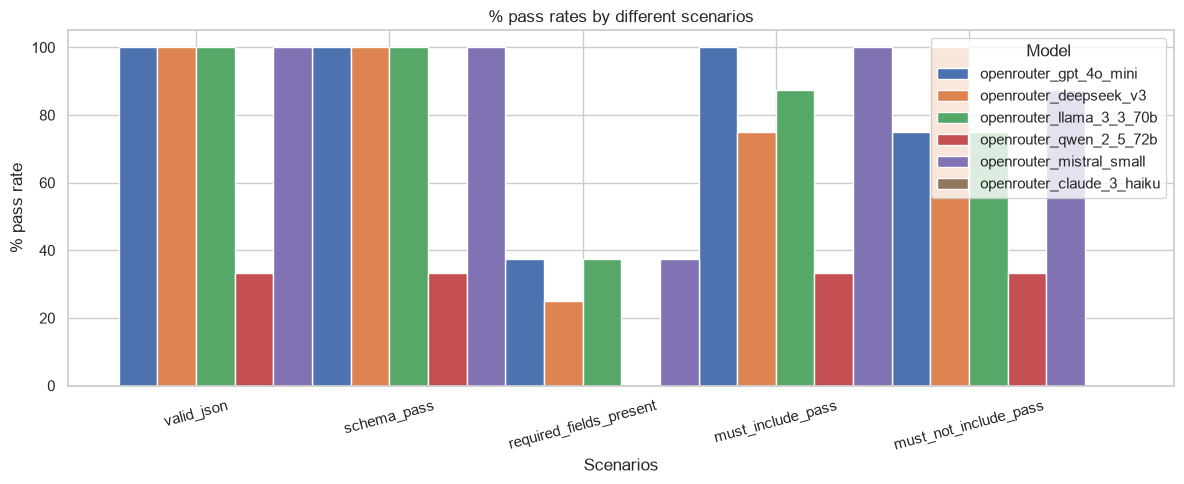

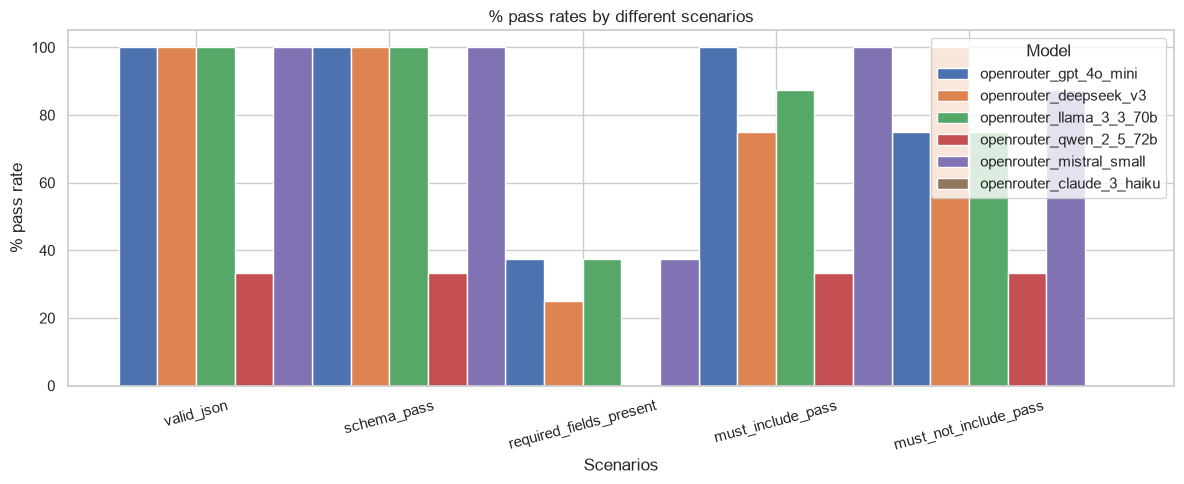

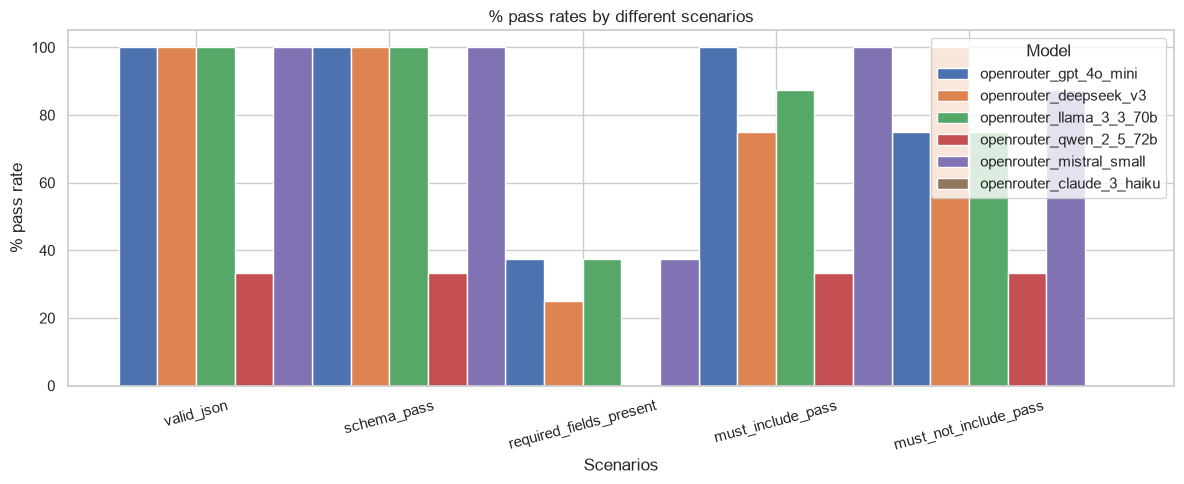

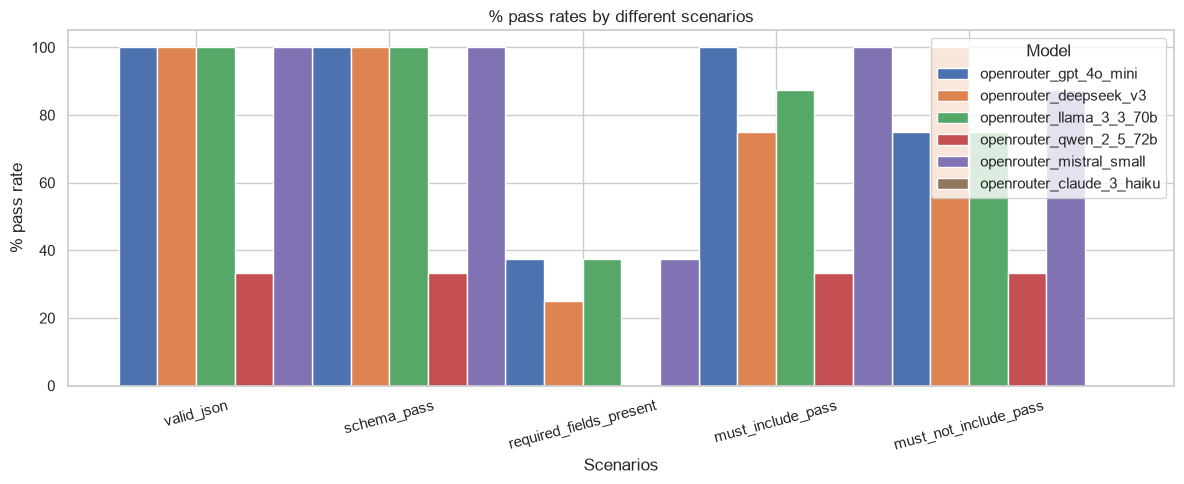

In [59]:
for col in pass_cols: 
    df[col] = df[col].astype(str).str.lower() == 'true'
    models = list(df['model_name'].unique())
    x = np.arange (len(pass_cols))
    width = 0.2
    plt.figure (figsize = (12, 5))

    for i, m in enumerate(models):
        sub = df[df['model_name'] == m]
        means = [sub[c].mean() * 100 for c in pass_cols]
        plt.bar(x + (i * width), means, width, label = m)

    plt.title ("% pass rates by different scenarios")
    plt.xticks(x + width * 1.5, pass_cols, rotation = 15)
    plt.ylabel('% pass rate')
    plt.xlabel('Scenarios')
    plt.legend(title = 'Model')
    plt.tight_layout()

In [60]:
valid_df = df[df['has_error'] == False].copy()
models = list(valid_df['model_name'].unique())

#Settings for aligning the columns of the chart (not important - don't toucn)
x = np.arange (len(models)) 
width = 0.3

#Calculate average latency of generate and refine
gen_latency = [valid_df[(valid_df['model_name'] == m) & (valid_df['task_type'] == 'generate')]['latency_seconds'].mean() for m in models]

ref_latency = [valid_df[(valid_df['model_name'] == m) & (valid_df['task_type'] == 'refine')]['latency_seconds'].mean() for m in models]

#Calculate average input & output tokens for 'generating' and 'refining' draft
gen_in_tokens = [valid_df[(valid_df['model_name'] == m) & (valid_df['task_type'] == 'generate')]['input_tokens'].mean() for m in models]
gen_out_tokens = [valid_df[(valid_df['model_name'] == m) & (valid_df['task_type'] == 'generate')]['output_tokens'].mean() for m in models]

ref_in_tokens = [valid_df[(valid_df['model_name'] == m) & (valid_df['task_type'] == 'refine')]['input_tokens'].mean() for m in models]
ref_out_tokens = [valid_df[(valid_df['model_name'] == m) & (valid_df['task_type'] == 'refine')]['output_tokens'].mean() for m in models]

#Calculate the average estimated cost for each models by 'generating' & 'refining'ArithmeticError
gen_cost = [valid_df[(valid_df['model_name'] == m) & (valid_df['task_type'] == 'generate')]['estimated_cost'].mean() for m in models]
ref_cost = [valid_df[(valid_df['model_name'] == m) & (valid_df['task_type'] == 'refine')]['estimated_cost'].mean() for m in models]

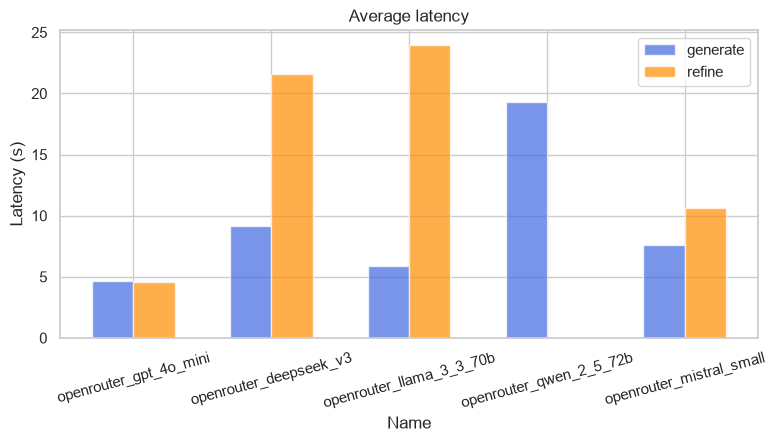

In [61]:
plt.figure (figsize = (9, 4))
plt.bar(x - width / 2, gen_latency, width, label = 'generate', alpha = 0.7, color = 'royalblue')
plt.bar (x + width / 2, ref_latency, width, label = 'refine', alpha = 0.7, color = 'darkorange')

plt.title ("Average latency")
plt.xticks(x, models, rotation = 15)
plt.xlabel('Name')
plt.ylabel ('Latency (s)')
plt.legend()
plt.show()

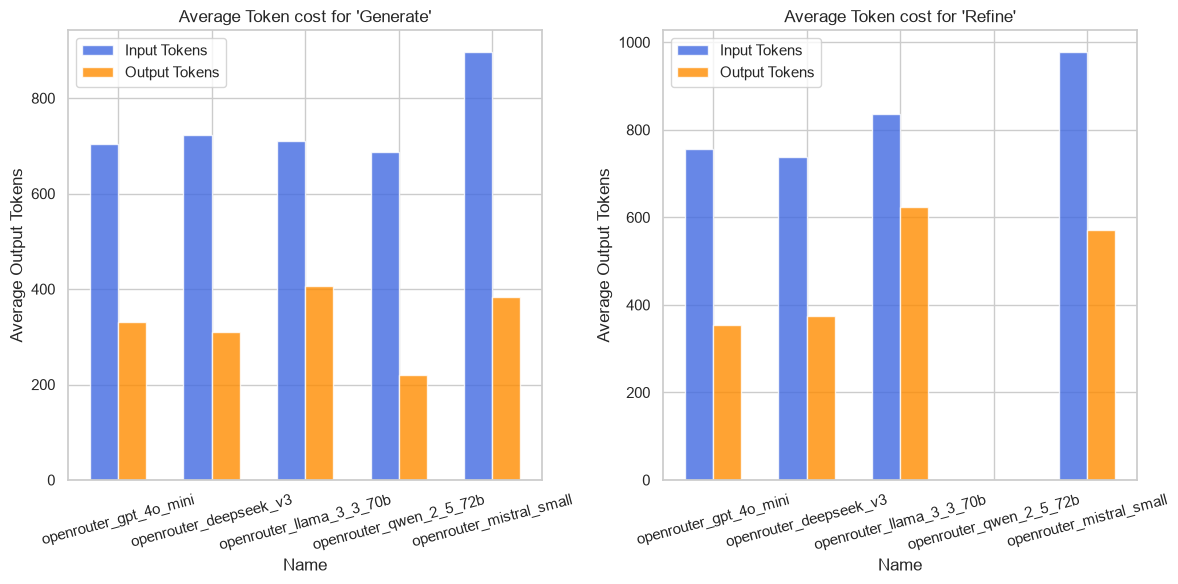

In [62]:
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (12, 6))

axes[0].bar (x - width / 2, gen_in_tokens, width, label = 'Input Tokens', color = 'royalblue', alpha = 0.8) 
axes[0].set_title ("Average Token cost for 'Generate'")
axes[0].set_xticks(x, models, rotation = 15)
axes[0].set_xlabel('Name')
axes[0].set_ylabel('Average Input Tokens')
axes[0].legend()

axes[0].bar (x + width / 2, gen_out_tokens, width, label = 'Output Tokens', color = 'darkorange', alpha = 0.8) 
axes[0].set_title ("Average Token cost for 'Generate'")
axes[0].set_xticks(x, models, rotation = 15)
axes[0].set_xlabel('Name')
axes[0].set_ylabel('Average Output Tokens')
axes[0].legend()

axes[1].bar (x - width / 2, ref_in_tokens, width, label = 'Input Tokens', color = 'royalblue', alpha = 0.8) 
axes[1].set_title ("Average Token cost for 'Refine'")
axes[1].set_xticks(x, models, rotation = 15)
axes[1].set_xlabel('Name')
axes[1].set_ylabel('Average Input Tokens')
axes[1].legend()

axes[1].bar (x + width / 2, ref_out_tokens, width, label = 'Output Tokens', color = 'darkorange', alpha = 0.8) 
axes[1].set_title ("Average Token cost for 'Refine'")
axes[1].set_xticks(x, models, rotation = 15)
axes[1].set_xlabel('Name')
axes[1].set_ylabel('Average Output Tokens')
axes[1].legend()

plt.tight_layout()
plt.show()

# Analysis
* Input tokens is higher because LLMs have to convert the users' requirements in questions into embedding vectors.
* Output tokens is low because tasks only required text generation (Formatting and structuring is manually controlled by program structure.)

=> This proves that the design of rendering helps reduce total cost by cutting output tokens

# Sorting models by 'Token Saving'
1st: gpt-4o-mini
2nd: deepseek v3
3rd: llama_3_3_70b


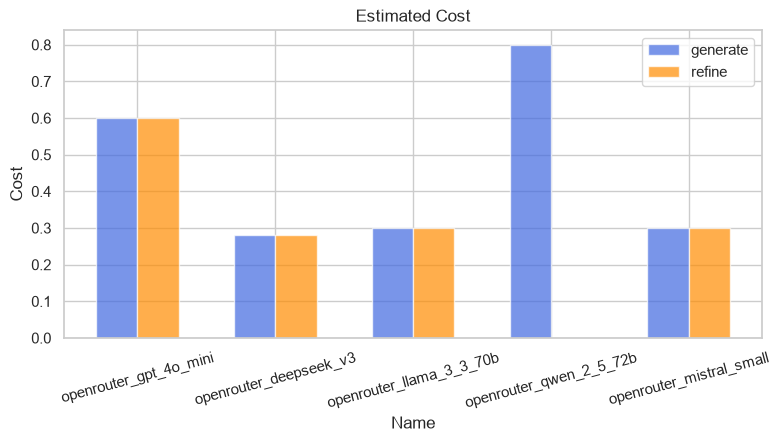

In [66]:
plt.figure (figsize = (9, 4))
plt.bar(x - width / 2, gen_cost, width, label = 'generate', alpha = 0.7, color = 'royalblue')
plt.bar(x + width / 2, ref_cost, width, label = 'refine', alpha = 0.7, color = 'darkorange')

plt.title ("Estimated Cost")
plt.xticks(x, models, rotation = 15)
plt.xlabel('Name')
plt.ylabel ('Cost')
plt.legend()
plt.show()